In [3]:
pip install llama-cpp-python[cuda] --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu121


Looking in indexes: https://pypi.org/simple, https://abetlen.github.io/llama-cpp-python/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.3/551.3 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.4 MB/s eta 0:00:00


In [7]:
!mkdir -p models
!wget -O models/T-lite-it-2.1-Q4_K_M.gguf \
https://huggingface.co/t-tech/T-lite-it-2.1-GGUF/resolve/main/T-lite-it-2.1-Q4_K_M.gguf


--2026-02-01 13:51:44--  https://huggingface.co/t-tech/T-lite-it-2.1-GGUF/resolve/main/T-lite-it-2.1-Q4_K_M.gguf
Resolving huggingface.co (huggingface.co)... 3.168.132.126, 3.168.132.38, 3.168.132.91, ...
Connecting to huggingface.co (huggingface.co)|3.168.132.126|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/6945512cac1d523483c5cd55/6112b3dd12e0e8fca22109972a9fd44df03ab32c6a0f5d62c93e4bbdf9d76e63?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27T-lite-it-2.1-Q4_K_M.gguf%3B+filename%3D%22T-lite-it-2.1-Q4_K_M.gguf%22%3B&Expires=1769957504&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiRXBvY2hUaW1lIjoxNzY5OTU3NTA0fX0sIlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjk0NTUxMmNhYzFkNTIzNDgzYzVjZDU1LzYxMTJiM2RkMTJlMGU4ZmNhMjIxMDk5NzJhOWZkNDRkZjAzYWIzMmM2YTBmNWQ2MmM5M2U0YmJkZjlkNzZlNjNcXD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSoifV19&Signature=Cxe3m8-F7zOf8Z2OBNKivsEXC

In [108]:
from llama_cpp import Llama
import json
import re
from sklearn.metrics import accuracy_score, recall_score,f1_score ,precision_score,confusion_matrix,classification_report,ConfusionMatrixDisplay
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [56]:
model = Llama(model_path = "/content/models/T-lite-it-2.1-Q4_K_M.gguf",seed = 42,temperature=0.2,n_gpu_layers=-1, n_ctx=4096)

llama_model_load_from_file_impl: using device CUDA0 (Tesla T4) - 10116 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /content/models/T-lite-it-2.1-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                     general.sampling.top_k i32              = 20
llama_model_loader: - kv   3:                     general.sampling.top_p f32              = 0.800000
llama_model_loader: - kv   4:                      general.sampling.temp f32              = 0.700000
llama_model_loader: - kv   5:                               general.name str              = Model
llama_model_loader: - kv   6:                         general.size_label str    

In [ ]:
with open(r'/content/sample_data/dataset_v2.5.json','r',encoding='utf-8') as file:
    dataset = json.load(file)

with open(r'/content/sample_data/temp.json','r',encoding='utf-8') as file:
    raw_dataset = json.load(file)


290

In [58]:
with open(r'/content/sample_data/prompt_event.txt','r', encoding='utf-8') as file:
    user_prompt = file.read()

user_prompt

'Входные данные — JSON с полями:\n- title: заголовок новости\n- body: краткое описание\nИспользуй информацию ТОЛЬКО из title и body.\nНе используй внешние знания.\nНе делай предположений, если они не следуют явно из текста.\nИгнорируй многоточия (...) и не предполагая скрытого содержания.\nПРАВИЛА АНАЛИЗА:\nis_event:\n- Определи, описывает ли текст конкретное экономическое, финансовое или корпоративное событие.\n- Инициативы, обсуждения и планы могут иметь is_event = true ТОЛЬКО если явно указан экономический эффект или совершившееся действие.\n- Движение рынка (индексы, цены, волатильность, ликвидность) считается событием.\nНЕ ЯВЛЯЕТСЯ СОБЫТИЕМ (is_event = false), если:\n- Если в тексте НЕТ факта произошедшего изменения или действия, то "is_event": false.\n- Текст содержит только ожидания, прогнозы, оценки аналитиков без факта изменения\n- Текст является анонсом, календарём или перечнем ожидаемых событий\n- Описывается участие в мероприятии, выступление, комментарий без решений\n- Упо

In [59]:
with open(r'/content/sample_data/system_file_prompt_event.txt','r', encoding='utf-8') as file:
    system_prompt = file.read()
system_prompt

'Ты — аналитик финансовых и корпоративных новостей. Твоя задача — определить, описывает ли текст конкретное экономическое, финансовое или корпоративное событие.'

In [60]:
def presiction_model(model,data,system_prompt,user_prompt):
    return model.create_chat_completion(
        messages = [
        {'role':'system','content':system_prompt},
        {'role':'user','content':user_prompt + data}
        ],
        response_format = {"type": "json_object"},
        max_tokens=2048
    )

In [95]:
def test_score(model,raw_dataset,system_prompt,user_prompt,dataset):
    y_true = []
    y_pred = []

    for i in tqdm(range(len(raw_dataset))):
        try:
          output = presiction_model(model = model,data = str(raw_dataset[i]),system_prompt = system_prompt,user_prompt = user_prompt)['choices'][0]['message']['content']
          pred = json.loads(output)
          print(f'Строка номер {i}')
          print(f'pred: {pred}')
          print(f'output: {output}')
          y_pred.append(pred['event']['is_event'])


          y_true.append(dataset[i]['event']['is_event'])
        except Exception as e:
            print(f"Ошибка: {e}")
            continue
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy}")
    return {'accuracy':accuracy,'y_true':y_true,'y_pred':y_pred}

In [25]:
y_true = ['true','true']
y_pred = ['true','true']

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


In [96]:
score = test_score(model = model,raw_dataset = raw_dataset,system_prompt = system_prompt,user_prompt = user_prompt,dataset =dataset)

  0%|          | 0/290 [00:00<?, ?it/s]

Llama.generate: 411 prefix-match hit, remaining 72 prompt tokens to eval
llama_perf_context_print:        load time =     565.21 ms
llama_perf_context_print: prompt eval time =     155.38 ms /    72 tokens (    2.16 ms per token,   463.37 tokens per second)
llama_perf_context_print:        eval time =    1969.36 ms /    79 runs   (   24.93 ms per token,    40.11 tokens per second)
llama_perf_context_print:       total time =    4708.86 ms /   151 tokens
llama_perf_context_print:    graphs reused =         76
Llama.generate: 411 prefix-match hit, remaining 68 prompt tokens to eval


Строка номер 0
pred: {'doc_id': 1, 'source_text': {'title': 'Подборка замещающих облигаций в евро: доходность — до 10% за полгода', 'body': 'Чем привлекателен выпуск Газпром Капитала'}, 'event': {'is_event': False}}
output: {
  "doc_id": 1,
  "source_text": {
    "title": "Подборка замещающих облигаций в евро: доходность — до 10% за полгода",
    "body": "Чем привлекателен выпуск Газпром Капитала"
  },
  "event": {
    "is_event": false
  }
}


llama_perf_context_print:        load time =     565.21 ms
llama_perf_context_print: prompt eval time =      93.22 ms /    68 tokens (    1.37 ms per token,   729.43 tokens per second)
llama_perf_context_print:        eval time =    1866.84 ms /    75 runs   (   24.89 ms per token,    40.17 tokens per second)
llama_perf_context_print:       total time =    4760.87 ms /   143 tokens
llama_perf_context_print:    graphs reused =         71
Llama.generate: 411 prefix-match hit, remaining 74 prompt tokens to eval


Строка номер 1
pred: {'doc_id': 1, 'source_text': {'title': 'Polymetal отчитался за III квартал. Запасы распродаются', 'body': 'Изучаем операционные результаты за III квартал 2023 года'}, 'event': {'is_event': False}}
output: {
  "doc_id": 1,
  "source_text": {
    "title": "Polymetal отчитался за III квартал. Запасы распродаются",
    "body": "Изучаем операционные результаты за III квартал 2023 года"
  },
  "event": {
    "is_event": false
  }
}


...

Строка номер 287
pred: {'doc_id': 1, 'source_text': {'title': 'В Азии нет единой динамики, нефть слегка дорожает', 'body': 'Рубль двигается разнонаправленно по отношению к мировым валютам'}, 'event': {'is_event': True}}
output: {
  "doc_id": 1,
  "source_text": {
    "title": "В Азии нет единой динамики, нефть слегка дорожает",
    "body": "Рубль двигается разнонаправленно по отношению к мировым валютам"
  },
  "event": {
    "is_event": true
  }
}


llama_perf_context_print:        load time =     565.21 ms
llama_perf_context_print: prompt eval time =      97.59 ms /    70 tokens (    1.39 ms per token,   717.25 tokens per second)
llama_perf_context_print:        eval time =    2180.60 ms /    89 runs   (   24.50 ms per token,    40.81 tokens per second)
llama_perf_context_print:       total time =    5215.07 ms /   159 tokens
llama_perf_context_print:    graphs reused =         86
Llama.generate: 411 prefix-match hit, remaining 74 prompt tokens to eval


Строка номер 288
pred: {'doc_id': 1, 'source_text': {'title': 'Совет директоров НКХП рекомендовал дивиденды за 2022 год в размере 14,62 рубля на акцию', 'body': 'Дата закрытия дивидендного реестра -\xa012 июля'}, 'event': {'is_event': True}}
output: {
  "doc_id": 1,
  "source_text": {
    "title": "Совет директоров НКХП рекомендовал дивиденды за 2022 год в размере 14,62 рубля на акцию",
    "body": "Дата закрытия дивидендного реестра -\u00a012 июля"
  },
  "event": {
    "is_event": true
  }
}


llama_perf_context_print:        load time =     565.21 ms
llama_perf_context_print: prompt eval time =      97.34 ms /    74 tokens (    1.32 ms per token,   760.26 tokens per second)
llama_perf_context_print:        eval time =    2195.85 ms /    90 runs   (   24.40 ms per token,    40.99 tokens per second)
llama_perf_context_print:       total time =    5574.50 ms /   164 tokens
llama_perf_context_print:    graphs reused =         87


Строка номер 289
pred: {'doc_id': 1, 'source_text': {'title': 'Мосбиржа прорабатывает возможность запуска фьючерса на внутренние цены на сахар', 'body': 'Сейчас среди инструментов срочного рынка - расчетный фьючерс на сахар-сырец, торгуемый на международной бирже Intercontinental Exchange'}, 'event': {'is_event': False}}
output: {
  "doc_id": 1,
  "source_text": {
    "title": "Мосбиржа прорабатывает возможность запуска фьючерса на внутренние цены на сахар",
    "body": "Сейчас среди инструментов срочного рынка - расчетный фьючерс на сахар-сырец, торгуемый на международной бирже Intercontinental Exchange"
  },
  "event": {
    "is_event": false
  }
}
Accuracy: 0.754325259515571


In [99]:
score['accuracy']

0.754325259515571

In [102]:
y_pred = score['y_pred']
y_true = score['y_true']
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

       False       0.54      0.82      0.65        82
        True       0.91      0.73      0.81       207

    accuracy                           0.75       289
   macro avg       0.73      0.77      0.73       289
weighted avg       0.81      0.75      0.77       289



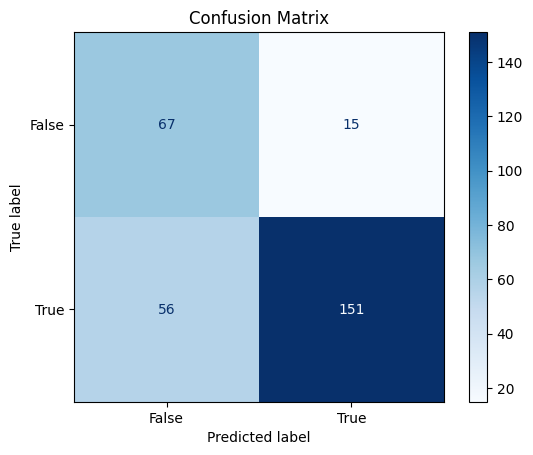

In [112]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels=['False','True'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()